In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
d=pd.read_csv(r"C:\Users\sivas\Downloads\Salary_Data.csv")
d

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [4]:
d.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [6]:
d.columns[d.isnull().any()]

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [7]:
d=d.drop(["Education Level"],axis=1)
d

,Age,Gender,Job Title,Years of Experience,Salary
0,32.0,Male,Software Engineer,5.0,90000.0
1,28.0,Female,Data Analyst,3.0,65000.0
2,45.0,Male,Senior Manager,15.0,150000.0
3,36.0,Female,Sales Associate,7.0,60000.0
4,52.0,Male,Director,20.0,200000.0
...,...,...,...,...,...
6699,49.0,Female,Director of Marketing,20.0,200000.0
6700,32.0,Male,Sales Associate,3.0,50000.0
6701,30.0,Female,Financial Manager,4.0,55000.0
6702,46.0,Male,Marketing Manager,14.0,140000.0


In [10]:
d["Gender"].value_counts

<bound method IndexOpsMixin.value_counts of 0         Male
1       Female
2         Male
3       Female
4         Male
         ...  
6699    Female
6700      Male
6701    Female
6702      Male
6703    Female
Name: Gender, Length: 6704, dtype: object>

In [11]:
d.info

<bound method DataFrame.info of        Age  Gender              Job Title  Years of Experience    Salary
0     32.0    Male      Software Engineer                  5.0   90000.0
1     28.0  Female           Data Analyst                  3.0   65000.0
2     45.0    Male         Senior Manager                 15.0  150000.0
3     36.0  Female        Sales Associate                  7.0   60000.0
4     52.0    Male               Director                 20.0  200000.0
...    ...     ...                    ...                  ...       ...
6699  49.0  Female  Director of Marketing                 20.0  200000.0
6700  32.0    Male        Sales Associate                  3.0   50000.0
6701  30.0  Female      Financial Manager                  4.0   55000.0
6702  46.0    Male      Marketing Manager                 14.0  140000.0
6703  26.0  Female        Sales Executive                  1.0   35000.0

[6704 rows x 5 columns]>

In [12]:
x=pd.get_dummies(d["Gender"])
x

,Female,Male,Other
0,False,True,False
1,True,False,False
2,False,True,False
3,True,False,False
4,False,True,False
...,...,...,...
6699,True,False,False
6700,False,True,False
6701,True,False,False
6702,False,True,False


In [14]:
d=pd.concat([d,x],axis=1)
d

,Age,Gender,Job Title,Years of Experience,Salary,Female,Male,Other
0,32.0,Male,Software Engineer,5.0,90000.0,False,True,False
1,28.0,Female,Data Analyst,3.0,65000.0,True,False,False
2,45.0,Male,Senior Manager,15.0,150000.0,False,True,False
3,36.0,Female,Sales Associate,7.0,60000.0,True,False,False
4,52.0,Male,Director,20.0,200000.0,False,True,False
...,...,...,...,...,...,...,...,...
6699,49.0,Female,Director of Marketing,20.0,200000.0,True,False,False
6700,32.0,Male,Sales Associate,3.0,50000.0,False,True,False
6701,30.0,Female,Financial Manager,4.0,55000.0,True,False,False
6702,46.0,Male,Marketing Manager,14.0,140000.0,False,True,False


In [15]:
d["Years of Experience"]=d["Years of Experience"].fillna(d["Years of Experience"].mean())
d["Years of Experience"]

0        5.0
1        3.0
2       15.0
3        7.0
4       20.0
        ... 
6699    20.0
6700     3.0
6701     4.0
6702    14.0
6703     1.0
Name: Years of Experience, Length: 6704, dtype: float64

In [16]:
d["Salary"]=d["Salary"].fillna(d["Salary"].mean())
d["Salary"]

0        90000.0
1        65000.0
2       150000.0
3        60000.0
4       200000.0
          ...   
6699    200000.0
6700     50000.0
6701     55000.0
6702    140000.0
6703     35000.0
Name: Salary, Length: 6704, dtype: float64

In [17]:
#pip install scikit-learn

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x=d[["Years of Experience"]]
y=d["Salary"]
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)
x_test

,Years of Experience
2794,19.0
2233,8.0
5559,3.0
6355,2.0
263,3.0
...,...
2820,32.0
3165,8.0
5947,0.0
6429,3.0


In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
from sklearn.metrics import r2_score

In [25]:
tr=LinearRegression()
tr.fit(x_train,y_train)

LinearRegression()

In [26]:
y_pred=tr.predict(x_test)
y_pred

array([192634.474479  , 114754.49957938,  79354.51098865, ...,
        58114.51783421,  79354.51098865,  72274.5132705 ])

In [27]:
tr.intercept_

58114.51783420501

In [28]:
r2_score(y_test,y_pred)

0.6434486563267621

In [29]:
a=np.array(4.7).reshape(-1,1)
b=tr.predict(a)

b

c:\Users\sivas\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([91390.5071095])

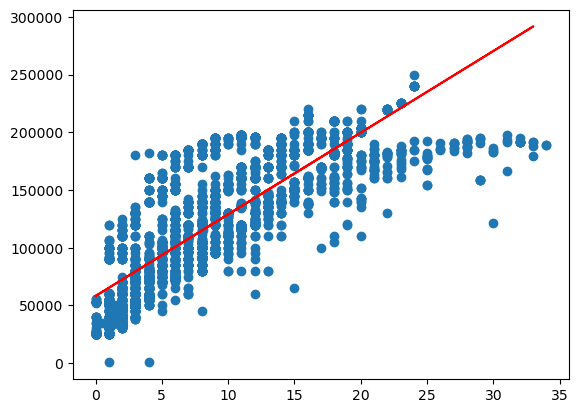

In [30]:
plt.scatter(x_train,y_train)
plt.plot(x_test,y_pred,color="red")
plt.show()